# Credit Card Fraud Detection with Deep Learning

This project compares two deep learning approaches for detecting fraudulent credit card transactions in tabular data:

1. A fully connected deep neural network (DNN)
2. A 1D convolutional neural network (CNN)

The objective is to evaluate which architecture performs better for highly imbalanced transaction data while demonstrating a practical fraud analytics workflow in Python.

> **Dataset note:** This notebook expects a local `creditcard.csv` file in the working directory. For GitHub portfolio use, pair this notebook with a README that explains the dataset source and setup steps.


## 1. Environment Setup and Imports

In [17]:
# Uncomment to install TensorFlow
# !pip install tensorflow

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, accuracy_score, roc_curve

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import Dense, Dropout, Conv1D, MaxPooling1D, Flatten
from tensorflow.keras.callbacks import EarlyStopping

## 2. Load and Inspect the Dataset

Load `creditcard.csv` and preview the structure of the transaction data:

In [18]:
df = pd.read_csv('creditcard.csv')
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


Check how many are normal vs. fraud:

In [19]:
df['Class'].value_counts(normalize=True)

,proportion
Class,
0,0.998273
1,0.001727


## 3. Data Preparation

- Split data into 80% train and 20% test
- Scale features so the network learns better

In [20]:
df.dropna(subset=['Class'], inplace=True)
X = df.drop('Class', axis=1).values
y = df['Class'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

## 4. Build a Fully Connected Deep Neural Network

Stack layers of neurons with dropout:

In [21]:
dnn = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid'),
])

dnn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['AUC'])

es = EarlyStopping(
    monitor='val_AUC',
    patience=5,
    mode='max',
    restore_best_weights=True
)

history = dnn.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=2048,
    callbacks=[es],
    verbose=0
)

print(f"DNN training complete. Best validation AUC: {max(history.history['val_AUC']):.4f}")

DNN training complete. Best validation AUC: 0.9333


## 5. Evaluate the DNN

Check AUC and accuracy, then plot the ROC curve:

DNN AUC: 0.9751, Accuracy: 0.9994


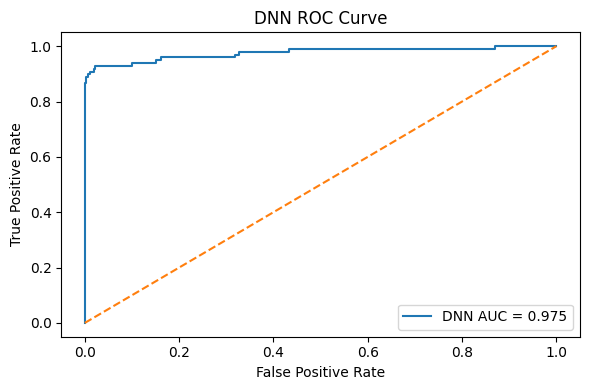

In [22]:
y_prob = dnn.predict(X_test, verbose=0).ravel()
auc = roc_auc_score(y_test, y_prob)
acc = accuracy_score(y_test, (y_prob > 0.5).astype(int))

print(f'DNN AUC: {auc:.4f}, Accuracy: {acc:.4f}')

fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f'DNN AUC = {auc:.3f}')
plt.plot([0, 1], [0, 1], '--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('DNN ROC Curve')
plt.legend()
plt.tight_layout()
plt.show()

## 6. Build a 1D CNN for Tabular Classification

Reshape data and use convolution layers:

In [23]:
X_train_c = X_train.reshape(-1, X_train.shape[1], 1)
X_test_c = X_test.reshape(-1, X_test.shape[1], 1)

cnn = Sequential([
    Input(shape=(X_train.shape[1], 1)),
    Conv1D(32, 3, activation='relu'),
    MaxPooling1D(2),
    Dropout(0.3),
    Conv1D(16, 3, activation='relu'),
    MaxPooling1D(2),
    Dropout(0.2),
    Flatten(),
    Dense(16, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid'),
])

cnn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['AUC'])

es_c = EarlyStopping(
    monitor='val_AUC',
    patience=5,
    mode='max',
    restore_best_weights=True
)

history_c = cnn.fit(
    X_train_c,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=2048,
    callbacks=[es_c],
    verbose=0
)

print(f"CNN training complete. Best validation AUC: {max(history_c.history['val_AUC']):.4f}")

CNN training complete. Best validation AUC: 0.9274


## 7. Evaluate the CNN

AUC, accuracy, and ROC plot:

CNN AUC: 0.9548, Accuracy: 0.9993


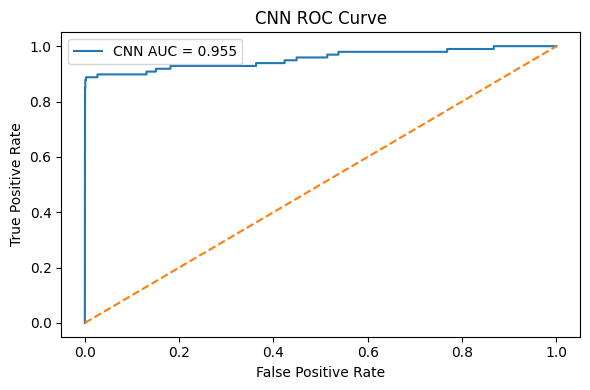

In [24]:
y_prob_c = cnn.predict(X_test_c, verbose=0).ravel()
auc_c = roc_auc_score(y_test, y_prob_c)
acc_c = accuracy_score(y_test, (y_prob_c > 0.5).astype(int))

print(f'CNN AUC: {auc_c:.4f}, Accuracy: {acc_c:.4f}')

fpr_c, tpr_c, _ = roc_curve(y_test, y_prob_c)
plt.figure(figsize=(6, 4))
plt.plot(fpr_c, tpr_c, label=f'CNN AUC = {auc_c:.3f}')
plt.plot([0, 1], [0, 1], '--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('CNN ROC Curve')
plt.legend()
plt.tight_layout()
plt.show()

## 8. Project Summary and Takeaways

This project compared a fully connected deep neural network and a 1D convolutional neural network for credit card fraud detection on imbalanced transaction data.

### Key takeaways
- The DNN delivered slightly stronger performance in this workflow.
- For structured transaction data, a simpler dense architecture can compete well with more specialized deep learning designs.
- Fraud detection requires more than raw accuracy because the positive class is rare, so ROC-AUC and threshold-aware evaluation matter.

### Portfolio relevance
This notebook demonstrates applied machine learning for financial risk modeling, imbalanced classification, and model comparison in a business-relevant fraud detection setting.
